# Western Balkans → EU Convergence Analysis

Do the six Western Balkan economies converge toward EU economic levels, and where is each stuck?

**Data:** dbt marts in `s_vesnamalenica` (`wb_fct_gap_to_eu`, `wb_fct_stuck_matrix`, `wb_fct_sigma_convergence`, `wb_fct_years_to_close`), built from World Bank WDI and WGI data. Convergence analysis window: 2014–2024.

**Scope:** six Western Balkan economies (ALB, BIH, XKX, MNE, MKD, SRB). EU-27 is distributional backdrop only.

## 1. Setup

Connect to the database and load the analysis-ready marts.

In [63]:
import sys
from pathlib import Path

# The notebook lives in notebooks/, but our database helper is in ingestion/.
# Add the repo root to the path so we can import it.
REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import pandas as pd
from ingestion.db import get_engine

# The analysis-ready marts, all built and tested in dbt.
SCHEMA = "s_vesnamalenica"
engine = get_engine()

# gap_to_eu: each country's value as a % of the EU benchmark, per indicator per year.
gap = pd.read_sql(f"SELECT * FROM {SCHEMA}.wb_fct_gap_to_eu", engine)

# stuck_matrix: each country-indicator classified as catching up / stuck / etc. over 2014–2024.
stuck = pd.read_sql(f"SELECT * FROM {SCHEMA}.wb_fct_stuck_matrix", engine)

# sigma_convergence: coefficient of variation of gap-to-EU across the six WB economies,
# per indicator per year, 2014–2024. Falling CV = the group is tightening (converging).
# Built in dbt from wb_fct_gap_to_eu; consumed here, not recomputed — the CV lives in the
# pipeline, the notebook just reads it.
sigma = pd.read_sql(f"SELECT * FROM {SCHEMA}.wb_fct_sigma_convergence", engine)

# years_to_close: OLS slope per country-indicator over 2014–2024, with status and
# closure_status. Full 34-entity mart; filtered per-section below.
ytc_all_df = pd.read_sql(f"SELECT * FROM {SCHEMA}.wb_fct_years_to_close", engine)

print(f"Loaded gap_to_eu:      {gap.shape[0]} rows, {gap.shape[1]} columns")
print(f"Loaded stuck_matrix:   {stuck.shape[0]} rows, {stuck.shape[1]} columns")
print(f"Loaded sigma:          {sigma.shape[0]} rows, {sigma.shape[1]} columns")
print(f"Loaded years_to_close: {ytc_all_df.shape[0]} rows, {ytc_all_df.shape[1]} columns")

Loaded gap_to_eu:      4624 rows, 12 columns
Loaded stuck_matrix:   272 rows, 13 columns
Loaded sigma:          44 rows, 6 columns
Loaded years_to_close: 40 rows, 15 columns


## 2. Scope

Restrict to 6 Western Balkan economies: the only convergence subjects.

In [64]:
# 6 Western Balkan economies — the only subjects of this convergence analysis.
# EU-27 and the EU benchmark are backdrop, not measured here.
#
# Two time scopes are used deliberately in this notebook:
#   - EDA and trajectory-shape checks (section 3) use the full 2008-2024
#     series, to catch reversals or noise the endpoint comparison would hide.
#   - Classified convergence stats (gap deltas, OLS slopes, stuck-matrix,
#     years-to-close) are restricted to 2014-2024, matching the marts.

WB_SIX = ["ALB", "BIH", "XKX", "MNE", "MKD", "SRB"]
WB_SIX = ["ALB", "BIH", "XKX", "MNE", "MKD", "SRB"]

gap_wb = gap[gap["country_iso3"].isin(WB_SIX)].copy()
stuck_wb = stuck[stuck["country_iso3"].isin(WB_SIX)].copy()

# Confirm the filter caught exactly six countries in each mart.
print("Economies in gap_wb:  ", sorted(gap_wb["country_iso3"].unique()))
print("Economies in stuck_wb:", sorted(stuck_wb["country_iso3"].unique()))
print()
print(f"gap_wb:   {gap_wb.shape[0]} rows  (6 economies × 8 indicators × 17 years, 2008-2024 = 816)")
print(f"stuck_wb: {stuck_wb.shape[0]} rows  (6 economies × 8 indicators = 48)")

Economies in gap_wb:   ['ALB', 'BIH', 'MKD', 'MNE', 'SRB', 'XKX']
Economies in stuck_wb: ['ALB', 'BIH', 'MKD', 'MNE', 'SRB', 'XKX']

gap_wb:   816 rows  (6 economies × 8 indicators × 17 years, 2008-2024 = 816)
stuck_wb: 48 rows  (6 economies × 8 indicators = 48)


## 3. EDA

Check the marts before drawing conclusions: value ranges, nulls where expected, series completeness, and trajectory shape.

Confirm the data is trustworthy:
- **Value ranges** are the gap-to-EU numbers physically plausible, or are there unit errors?
- **Nulls** do missing values appear only where we expect them (Kosovo has no productivity data)?
- **Completeness** does every economy have a full 2008–2024 series?

In [65]:
# Value range per indicator — a min/max that's wildly off would signal a
# unit error or a bad benchmark. Gap-to-EU is a %, so values sit roughly 0–300.
print("Gap-to-EU range per indicator (all six economies, all years):")
print(
    gap_wb.groupby("friendly_name")["gap_to_eu"]
    .agg(["min", "max", "mean", "count"])
    .round(1)
)
print()

# (b) Where are the nulls? Expect Kosovo productivity to be the only gap.
print("Rows with missing gap-to-EU, by indicator:")
print(gap_wb[gap_wb["gap_to_eu"].isna()].groupby("friendly_name").size())
print()

# (c) Does every economy have a complete series? 8 indicators × 17 years = 136 rows each.
print("Rows per economy (expect 136 each):")
print(gap_wb.groupby("country_iso3").size())

Gap-to-EU range per indicator (all six economies, all years):
                                         min     max   mean  count
friendly_name                                                     
FDI net inflows (% GDP)               -629.6  1073.5  217.7    102
GDP per capita PPP                      15.3    51.7   35.0    102
Gross fixed capital formation (% GDP)   81.0   169.3  117.8    102
Labour force participation (%)          58.7   110.3   88.3    100
Productivity (GDP per worker)           27.6    62.8   46.4     85
Trade (% GDP)                           71.0   164.0  111.0    102
Unemployment total (%)                 122.2   655.9  230.5    100
Youth unemployment (%)                  95.3   335.2  187.5     95

Rows with missing gap-to-EU, by indicator:
friendly_name
Labour force participation (%)     2
Productivity (GDP per worker)     17
Unemployment total (%)             2
Youth unemployment (%)             7
dtype: int64

Rows per economy (expect 136 each):
country_iso3

## What the check shows:

- All 6 economies have a complete 2008–2024 series (136 rows each).
- Missing values appear only where expected: Kosovo has no productivity data (17 nulls), plus a few scattered labour/unemployment gaps already noted in the data dictionary.
- The classified indicators (GDP per capita, productivity, unemployment, youth unemployment) have plausible ranges over the classified 2014–2024 window. The full 2008–2024 range is wider: unemployment's top 3 gap values (MKD 2008: 468.5, XKX 2009: 492.9, XKX 2008: 655.9) all fall in 2008–2009, before the classified window starts, and likely reflect early-period measurement noise rather than a real unemployment spike. They don't affect any classified stat.
- FDI is an exception even inside the classified window: its gap-to-EU swings from −630% to +1074%, driven mainly by Montenegro's volatile series (3 of the 6 most extreme country-year values are MNE). This is consistent with lumpy FDI in a small economy rather than a data error, and confirms FDI can't be read as a convergence ratio, consistent with it being descriptive-only, not classified.

### 3.2 Trajectory shape

The stuck-matrix compares only two years (2014 and 2024). But two endpoints can hide a lot — a country that converged, crashed, and recovered would look identical to one that climbed steadily. Before trusting the "catching up" labels, plotting the full 2008–2024 path for the headline indicator, GDP per capita.

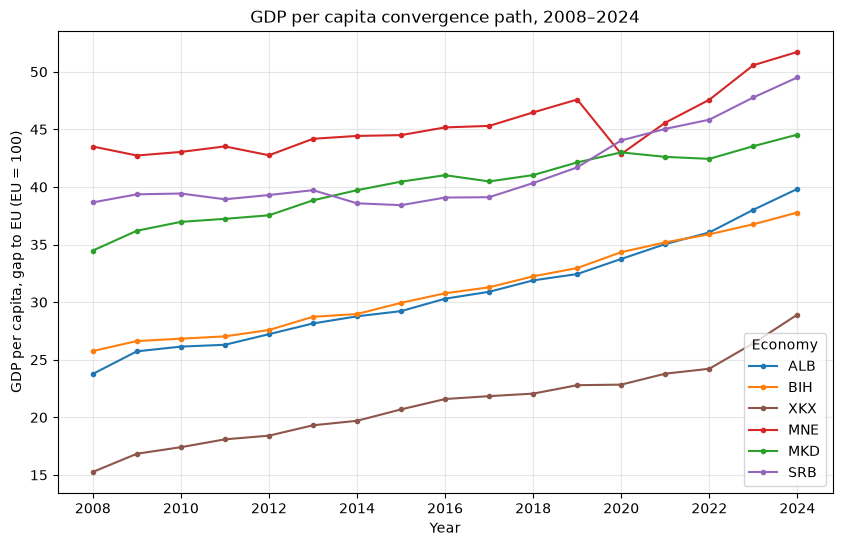

In [66]:
import matplotlib.pyplot as plt

# Plot the full GDP-per-capita gap path for each economy, 2008–2024.
# want to see whether catch-up is steady or hides crashes/reversals
# that the 2014-vs-2024 comparison would miss.
gdp = gap_wb[gap_wb["friendly_name"] == "GDP per capita PPP"]

# One colour per economy, matching the slope chart we'll build later.
COUNTRY_COLOURS = {
    "ALB": "#1f77b4", "BIH": "#ff7f0e", "MKD": "#2ca02c",
    "MNE": "#d62728", "SRB": "#9467bd", "XKX": "#8c564b",
}

fig, ax = plt.subplots(figsize=(10, 6))
for iso3 in WB_SIX:
    series = gdp[gdp["country_iso3"] == iso3].sort_values("year")
    ax.plot(series["year"], series["gap_to_eu"],
            marker="o", markersize=3, label=iso3, color=COUNTRY_COLOURS[iso3])

ax.set_xlabel("Year")
ax.set_ylabel("GDP per capita, gap to EU (EU = 100)")
ax.set_title("GDP per capita convergence path, 2008–2024")
ax.legend(title="Economy")
ax.grid(alpha=0.3)
plt.show()

**What the trajectory shows:**
- 5 of 6 economies converge steadily across the whole period, no hidden crashes or reversals, so the 2014-2024 endpoint comparison is a fair summary of their paths.
- **Montenegro is the exception:** a sharp drop in 2019-2020 (the COVID shock, hitting its tourism-heavy economy hard), followed by fast recovery. Because of this dip, Montenegro's GDP endpoint delta (+7.29) overstates its slope-based trend (+5.90) by about 24% - both figures appear below; the slope is the more reliable read of the underlying pace.
- Convergence was already underway before 2014. The early years (2008–2012) show a plateau, the financial-crisis aftermath stalled progress but did not reverse it. The 2014-2024 window therefore captures the recent, steadier phase of a longer catch-up.

### 3.3 Reference economies — "the path they might follow"

6 WB economies are still catching up. To see where that path leads, we plot two kinds of reference:

- **Recent EU entrants (Croatia, Bulgaria, Romania)** — economies that recently completed accession. They mark the path the 6 might follow.
- **Slovenia** — the ex-Yugoslav economy that already completed convergence. It marks the finish line.

First, check where these reference economies actually sit on the GDP-per-capita gap before adding them to the chart.

In [67]:
# Reference economies: the "path they might follow."
# Recent entrants (HRV, BGR, ROU), required as the path reference.
# Slovenia (SVN) — the ex-Yugoslav economy that completed convergence (finish line).

refs = ["HRV", "BGR", "ROU", "SVN"]
ref_gdp = gap[
    (gap["country_iso3"].isin(refs)) & (gap["friendly_name"] == "GDP per capita PPP")
][["country_iso3", "year", "gap_to_eu"]]

# Show each reference economy's 2014 and 2024 position
print("Reference economies — GDP per capita gap-to-EU:")
for iso3 in refs:
    s = ref_gdp[ref_gdp["country_iso3"] == iso3].sort_values("year")
    v2014 = s[s["year"] == 2014]["gap_to_eu"].values
    v2024 = s[s["year"] == 2024]["gap_to_eu"].values
    print(f"  {iso3}: 2014 = {v2014[0] if len(v2014) else 'NA':.1f}  →  2024 = {v2024[0] if len(v2024) else 'NA':.1f}")

Reference economies — GDP per capita gap-to-EU:
  HRV: 2014 = 61.3  →  2024 = 78.8
  BGR: 2014 = 50.5  →  2024 = 63.0
  ROU: 2014 = 60.6  →  2024 = 74.5
  SVN: 2014 = 81.1  →  2024 = 89.5


**What the reference positions show:**
The reference economies form 3 clear tiers with almost no overlap:
- 6 WB economies sit at 29–52% of the EU level (2024).
- The recent entrants sit higher — Bulgaria 63, Romania 75, Croatia 79.
- Slovenia, which completed convergence, sits at 90.

Even Montenegro, the strongest WB economy at 52, is still 11 points below Bulgaria, the lowest recent entrant. The "path they might follow" is a real, visible gap: the 6 have not yet reached the rung the recent entrants occupy.

### Checking the cohort question

A natural framing is "ex-Yugoslav economies vs Albania." But does the data actually show a cohort split, or does each economy behave individually? Compare average gap-change on the convergence indicators, grouped by ex-Yugoslav status.

In [68]:
# Does the ex-Yugoslav / Albania split actually explain convergence differences?
# Compare average gap-change on the CLASSIFIED convergence indicators only.
conv = stuck_wb[stuck_wb["bucket"] == "convergence"].copy()

# Per-economy gap-change, with the ex_yugoslav flag, for GDP per capita specifically
# (the cleanest convergence indicator — no Kosovo no_data hole).
gdp_change = conv[conv["friendly_name"] == "GDP per capita PPP"][
    ["country_iso3", "ex_yugoslav", "gap_change"]
].sort_values("gap_change", ascending=False)

print("GDP per capita gap-change by economy (2014→2024):")
print(gdp_change.to_string(index=False))
print()

# Group average — is there a real cohort difference?
print("Average GDP gap-change by cohort:")
print(conv[conv["friendly_name"] == "GDP per capita PPP"]
      .groupby("ex_yugoslav")["gap_change"].agg(["mean", "count"]).round(2))

GDP per capita gap-change by economy (2014→2024):
country_iso3  ex_yugoslav  gap_change
         ALB        False       11.06
         SRB         True       10.93
         XKX         True        9.22
         BIH         True        8.81
         MNE         True        7.29
         MKD         True        4.82

Average GDP gap-change by cohort:
              mean  count
ex_yugoslav              
False        11.06      1
True          8.21      5


**What the cohort check shows:**
There is no clean cohort split on income convergence. Albania (1 non-ex-Yugoslav economy) posts the largest gain (+11), but Serbia, ex-Yugoslav,is right behind it (+11), while Macedonia, also ex-Yugoslav, is lowest (+4.8). The ex-Yugoslav economies span the entire range rather than clustering. The shared Yugoslav legacy does not predict convergence speed; differences are economy-by-economy. (Note: with only 1 non-ex-Yugoslav economy, this is a descriptive observation about the *absence* of a cohort pattern, not a statistical between-group claim.)

## 4. Findings & visualizations

3 findings emerge from the analysis.

**1. Income is catching up faster than productivity.**
All 6 economies narrowed their GDP-per-capita gap to the EU over 2014-2024 (gains of 4.8 to 11.1 points). But their productivity gaps barely moved (gains of 1.1 to 5.8 points), and North Macedonia's productivity is effectively stuck (OLS slope 0.009 pts/year - statistically flat; the 1.06-pt endpoint figure is noise, not a trend). Income can rise faster than productivity through remittances, consumption, and workers moving out of unemployment, but productivity is what makes catch-up durable. This raises a question the data alone can't settle: whether the income convergence rests on solid foundations.

**2. The obvious grouping does not explain the differences.**
A natural framing is "ex-Yugoslav economies versus Albania." The data does not support it. Albania posts the largest income gain (+11.1), but Serbia, ex-Yugoslav, is right behind it (+10.9), while Macedonia, also ex-Yugoslav, is lowest (+4.8). The ex-Yugoslav economies span the entire range rather than clustering. The shared Yugoslav legacy does not predict convergence speed; differences are economy-by-economy. (With only 1 non-ex-Yugoslav economy, this is a descriptive observation about the absence of a cohort pattern, not a statistical between-group claim.)

**3. Where each is stuck: the exceptions.**
- **Macedonia:** productivity stalled (OLS slope 0.009 pts/year, statistically flat over the decade).
- **Montenegro:** unemployment diverged from the EU 2014-2020 (slope +5.21/yr on total unemployment, sustained and verified year-by-year) but the trend has reversed since: from its 2020 peak, the gap has narrowed every year through 2024 (slope -13.46/yr, 2020-2024), partially unwinding the earlier divergence. The rise predates COVID by six years, so the two are not causally linked despite the coincidence in timing with Montenegro's separate 2020 income dip.
- **Kosovo:** cannot be assessed on productivity at all; the World Bank series has no data. Reported as a finding, not hidden.

The visualizations below show the convergence paths, the income-versus-productivity contrast, and the status of each economy across indicators.

### 4.1 The convergence path and where it leads

Plotting the 6 economies over time, together with recent EU entrants (Croatia, Bulgaria, Romania) and Slovenia, shows both the path and the destination. The recent entrants mark the rung the six are climbing toward; Slovenia marks the finish line of completed convergence.

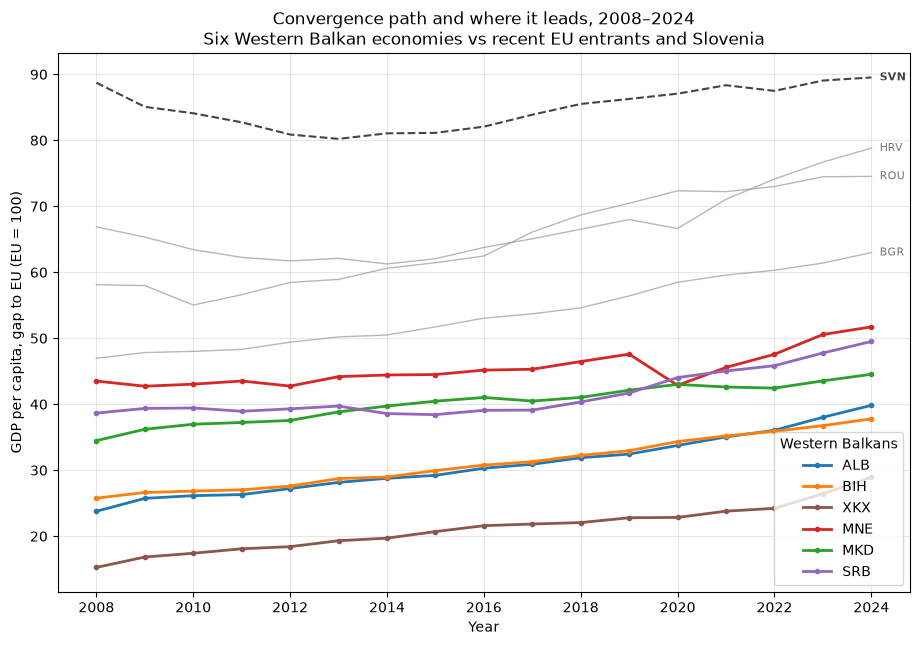

In [69]:
# The convergence path with reference economies.
# 6 WB economies (coloured) = the subjects.
# Recent entrants HRV/BGR/ROU (thin grey) = the path they might follow.
# Slovenia (dashed) = the finish line of completed convergence.

indicator = "GDP per capita PPP"

fig, ax = plt.subplots(figsize=(11, 7))

# --- Reference layer first, so the WB lines sit on top ---

# Recent entrants: thin grey lines, labelled once at their 2024 end.
for iso3 in ["HRV", "BGR", "ROU"]:
    s = gap[(gap["country_iso3"] == iso3) &
            (gap["friendly_name"] == indicator)].sort_values("year")
    ax.plot(s["year"], s["gap_to_eu"], color="#999999", linewidth=1, alpha=0.7)
    last = s.iloc[-1]
    ax.annotate(iso3, xy=(last["year"], last["gap_to_eu"]),
                xytext=(6, 0), textcoords="offset points",
                va="center", fontsize=8, color="#777777")

# Slovenia: dashed reference line (the finish line).
svn = gap[(gap["country_iso3"] == "SVN") &
          (gap["friendly_name"] == indicator)].sort_values("year")
ax.plot(svn["year"], svn["gap_to_eu"], color="#444444",
        linewidth=1.5, linestyle="--")
svn_last = svn.iloc[-1]
ax.annotate("SVN", xy=(svn_last["year"], svn_last["gap_to_eu"]),
            xytext=(6, 0), textcoords="offset points",
            va="center", fontsize=8, color="#444444", weight="bold")

# --- 6  WB economies on top ---
COUNTRY_COLOURS = {
    "ALB": "#1f77b4", "BIH": "#ff7f0e", "MKD": "#2ca02c",
    "MNE": "#d62728", "SRB": "#9467bd", "XKX": "#8c564b",
}
for iso3 in WB_SIX:
    s = gap[(gap["country_iso3"] == iso3) &
            (gap["friendly_name"] == indicator)].sort_values("year")
    ax.plot(s["year"], s["gap_to_eu"], marker="o", markersize=3,
            linewidth=2, label=iso3, color=COUNTRY_COLOURS[iso3])

ax.set_xlabel("Year")
ax.set_ylabel("GDP per capita, gap to EU (EU = 100)")
ax.set_title("Convergence path and where it leads, 2008–2024\n"
             "Six Western Balkan economies vs recent EU entrants and Slovenia")
ax.legend(title="Western Balkans", loc="lower right")
ax.grid(alpha=0.3)
plt.show()

**What the path shows:**
3 tiers are visible, and the gap between the bottom two is widening, not holding steady. The 6 WB economies climb steadily (tier average 33.4 -> 42.1 points, 2014-2024), but the recent entrants climb faster in absolute terms (57.5 -> 72.1), so the gap between the two tiers grew from 24.1 to 30.1 points over the decade - most of that widening happened before 2019. The 6 are not just failing to close the distance to the entrants; that 
distance is growing. Slovenia shows no sign of having "arrived" and stopped: its gap-to-EU rose steadily across the whole window (81.1 -> 89.5), at a pace similar to several of the WB six, with no flattening visible in this data.

### 4.2 Income versus productivity

The path chart shows income converging. But convergence on *what*? Comparing GDP per capita against productivity, side by side, shows the two moving at different speeds, the core of the first finding.

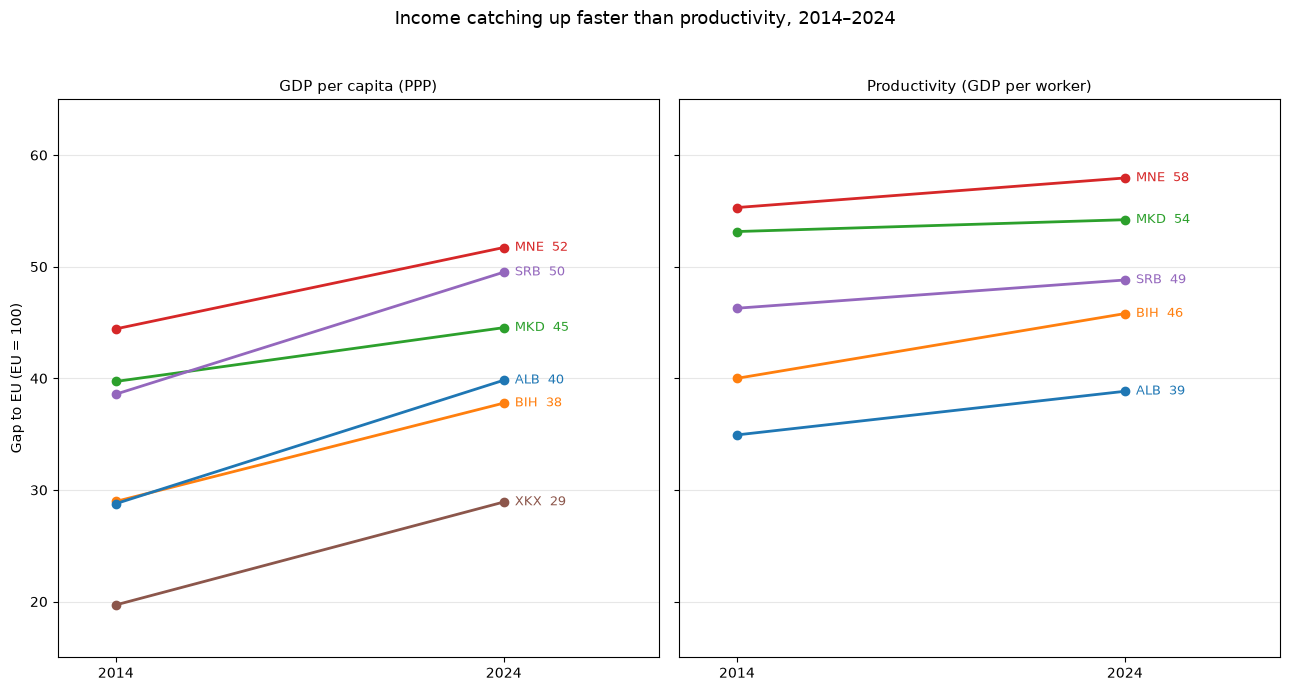

In [70]:
# Slope chart: GDP per capita vs productivity, 6 WB economies, 2014-2024.
# Shared y-axis so the two panels are directly comparable, steeper slope
# means faster catch-up. This is where "income outpaces productivity" is visible.

conv = stuck_wb[stuck_wb["bucket"] == "convergence"].copy()

indicators = [
    ("GDP per capita PPP", "GDP per capita (PPP)"),
    ("Productivity (GDP per worker)", "Productivity (GDP per worker)"),
]

fig, axes = plt.subplots(1, 2, figsize=(13, 7), sharey=True)

for ax, (friendly, title) in zip(axes, indicators):
    panel = conv[conv["friendly_name"] == friendly].dropna(subset=["gap_2014", "gap_2024"])
    panel = panel.sort_values("gap_2024").reset_index(drop=True)
    last_y = None
    for _, row in panel.iterrows():
        colour = COUNTRY_COLOURS[row["country_iso3"]]
        ax.plot([0, 1], [row["gap_2014"], row["gap_2024"]],
                marker="o", linewidth=2, color=colour)
        y = row["gap_2024"]
        if last_y is not None and abs(y - last_y) < 1.5:
            y = last_y + 1.5
        ax.annotate(
            f"{row['country_iso3']}  {row['gap_2024']:.0f}",
            xy=(1, row["gap_2024"]),
            xytext=(8, (y - row["gap_2024"]) * 4),
            textcoords="offset points",
            va="center", fontsize=9, color=colour,
        )
        last_y = y
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["2014", "2024"])
    ax.set_xlim(-0.15, 1.4)
    ax.set_ylim(15, 65)
    ax.set_title(title, fontsize=11)
    ax.grid(axis="y", alpha=0.3)

axes[0].set_ylabel("Gap to EU (EU = 100)")
fig.suptitle("Income catching up faster than productivity, 2014–2024", fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

**What the comparison shows:**
On the same scale, the difference is clear. GDP-per-capita gaps close steeply: every economy climbs several points toward the EU. Productivity gaps barely move; the lines are nearly flat, and Macedonia's is the flattest. Income is converging nearly 3 times as fast as productivity (mean gain 8.69 points vs 3.19). Kosovo appears only in the left panel, it has no productivity data, so its absence on the right is shown honestly rather than filled with a placeholder.

### 4.3 Status across indicators: where each is stuck

The final view classifies each economy on each indicator: catching up, stuck, or falling behind over 2014–2024. Only indicators where movement toward the EU is unambiguously convergence are classified (GDP, productivity, and the two unemployment measures). GDP and productivity use a tighter deadband (+/-0.2 pts/yr) than the two unemployment measures (+/-2.0 pts/yr), reflecting their different volatility: see the years-to-close methodology note. Status labels are direction-of-travel classifications, not measures of speed, and aren't directly comparable in magnitude across columns. The point of this chart is the exceptions — the cells that are not green.

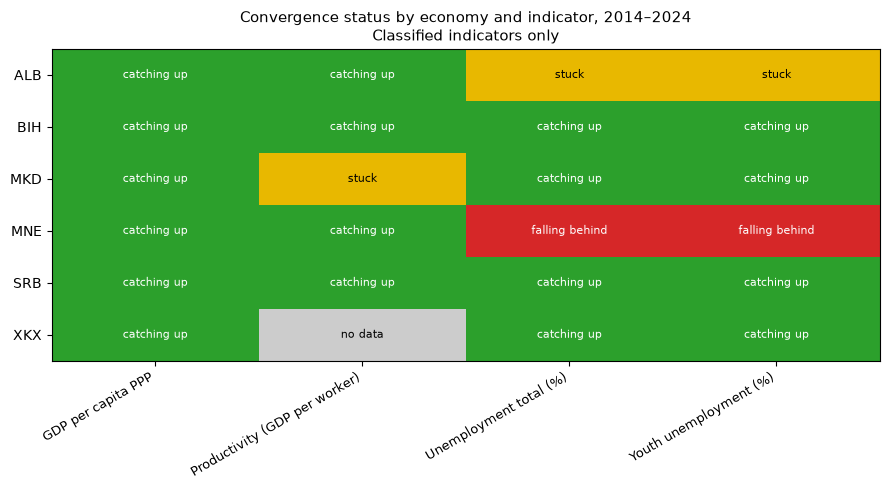

In [71]:
from matplotlib.colors import ListedColormap

# Status heatmap: 6 economies × 4 classified indicators.
# Context indicators are excluded. They carry no convergence classification.
# The point of this chart is the non-green cells: where each economy is stuck.

CLASSIFIED = [
    "GDP per capita PPP",
    "Productivity (GDP per worker)",
    "Unemployment total (%)",
    "Youth unemployment (%)",
]

hm = stuck_wb[stuck_wb["friendly_name"].isin(CLASSIFIED)].copy()
status_pivot = hm.pivot(index="country_iso3", columns="friendly_name", values="status")
status_pivot = status_pivot.reindex(columns=CLASSIFIED)

# Map each status to a colour: green = good, amber = flat, red = bad, grey = missing.
status_codes = {"catching_up": 0, "stuck": 1, "falling_behind": 2, "no_data": 3}
code_grid = status_pivot.replace(status_codes).astype(float)
cmap = ListedColormap(["#2ca02c", "#e8b800", "#d62728", "#cccccc"])

fig, ax = plt.subplots(figsize=(9, 5))
ax.imshow(code_grid.values, cmap=cmap, vmin=0, vmax=3, aspect="auto")

ax.set_xticks(range(len(CLASSIFIED)))
ax.set_xticklabels(CLASSIFIED, rotation=30, ha="right", fontsize=9)
ax.set_yticks(range(len(status_pivot.index)))
ax.set_yticklabels(status_pivot.index, fontsize=10)

# Label every cell with its status.
for i, country in enumerate(status_pivot.index):
    for j, ind in enumerate(CLASSIFIED):
        val = status_pivot.loc[country, ind]
        label = "" if pd.isna(val) else val.replace("_", " ")
        ax.text(j, i, label, ha="center", va="center", fontsize=8,
                color="white" if val in ("catching_up", "falling_behind") else "black")

ax.set_title("Convergence status by economy and indicator, 2014–2024\n"
             "Classified indicators only", fontsize=11)
fig.tight_layout()
plt.show()

**What the status grid shows:**
Most cells are green. Every economy is nominally moving toward the EU on most indicators. But "catching up" here means only that the gap moved in the right direction by at least two points over a decade; it is direction, not speed, and much of that movement is small (the income-versus-productivity chart above shows how small). The chart earns its place through the exceptions:

- **Albania: unemployment total and youth unemployment: stuck.** No meaningful movement over the decade on either measure.
- **Macedonia: productivity: stuck.** No meaningful movement over the decade.
- **Montenegro: unemployment total: falling behind.** Unemployment total: falling behind on the full 2014-2024 slope (+5.21/yr, a clear divergence), but this reverses after 2020, narrowing every year since (slope -13.46/yr, 2020-2024). **youth unemployment: falling behind, but only marginally** The slope (+2.004/yr) clears the +/-2.0 deadband by 0.004, effectively a coin flip. Its post-peak path is less clean than total unemployment's: after peaking later (2021, not 2020) it fell for 2 years, then ticked back up in 2024 (143.63 -> 157.65). See Finding #3 for the fuller trajectory.
- **Kosovo: productivity: no data.** Cannot be assessed; shown as grey rather than hidden.

Status here uses the same slope-based method as the years-to-close analysis, rather than a simple 2014-vs-2024 endpoint comparison. The two marts agree on every classification's direction and substance, though label vocabulary 
differs slightly between them (stuck_matrix uses "stuck"/"falling_behind", years_to_close uses "stalled"/"diverging" for the same cases).

## 4.4 Sigma-convergence: is the group tightening, or is one country moving?

The gap-to-EU and stuck-matrix answer *per-country* questions. Sigma-convergence asks a different one: is the **spread across the six economies shrinking** over time? A tightening spread means the group is converging as a bloc, the laggards closing on the leaders, not just one country pulling ahead.

I measure spread with the **coefficient of variation** (CV = standard deviation ÷ mean) of each indicator's gap-to-EU, computed per year in the `wb_fct_sigma_convergence` mart. CV is scale-free, so it does not shrink merely because the average level rises as everyone converges upward.

**Read this chart backwards from the others:** here, a line going **down** means convergence (economies becoming more alike). That is the opposite direction from the gap-to-EU charts, where up meant catching up.

Productivity runs five-country (Kosovo has no productivity data); the other 3 run six-country. This is a descriptive trend, not a significance test, at n=5-6 (productivity runs five-country, Kosovo has no productivity data), p-values are not defensible.

Total unemployment's dispersion peaks sharply in 2020; the other three indicators show no comparable disruption that year, GDP dispersion declines steadily throughout, productivity dips in 2020 and rebounds in 
2021, and youth unemployment had already peaked in 2018.

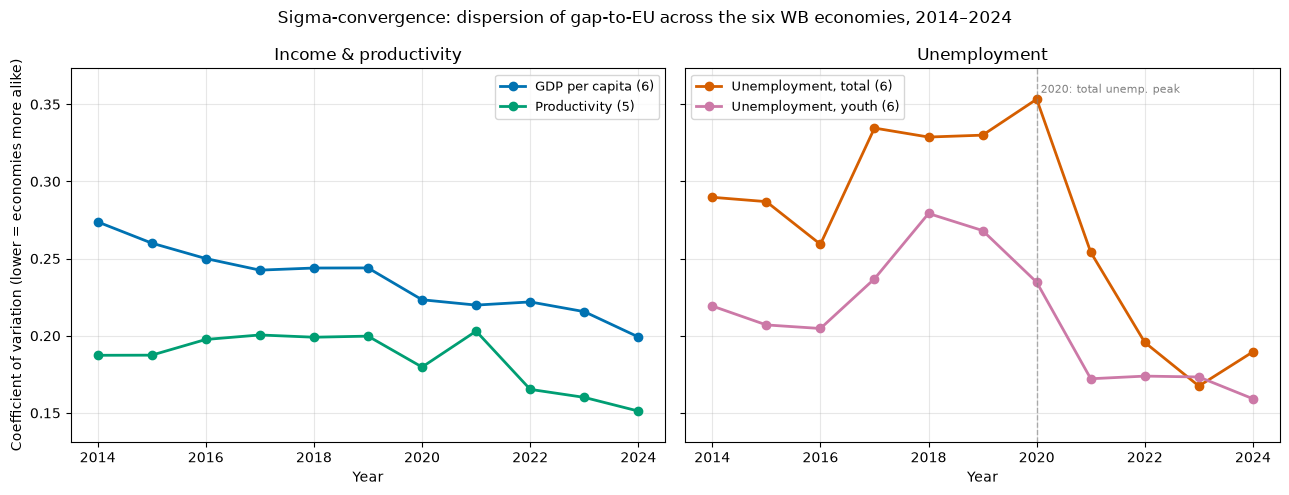

In [72]:
import matplotlib.pyplot as plt

# This chart is a DRAFT to verify the finding,
# the presentation version gets rebuilt in Tableau off the same mart.


colours = {
    "NY.GDP.PCAP.PP.KD": "#0072B2",   # blue
    "SL.GDP.PCAP.EM.KD": "#009E73",   # green
    "SL.UEM.TOTL.NE.ZS": "#D55E00",   # vermillion
    "SL.UEM.1524.NE.ZS": "#CC79A7",   # purple
}
labels = {
    "NY.GDP.PCAP.PP.KD": "GDP per capita (6)",
    "SL.GDP.PCAP.EM.KD": "Productivity (5)",
    "SL.UEM.TOTL.NE.ZS": "Unemployment, total (6)",
    "SL.UEM.1524.NE.ZS": "Unemployment, youth (6)",
}

panels = {
    "Income & productivity":  ["NY.GDP.PCAP.PP.KD", "SL.GDP.PCAP.EM.KD"],
    "Unemployment":           ["SL.UEM.TOTL.NE.ZS", "SL.UEM.1524.NE.ZS"],
}

# Shared y-limits across both panels so the two topics are visually comparable.
ymin = sigma["cv_gap"].min() - 0.02
ymax = sigma["cv_gap"].max() + 0.02

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for ax, (title, codes) in zip(axes, panels.items()):
    for code in codes:
        d = sigma[sigma["indicator_code"] == code].sort_values("year")
        ax.plot(d["year"], d["cv_gap"], marker="o", color=colours[code],
                label=labels[code], linewidth=2)
    if title == "Unemployment":
        # Total unemployment dispersion peaks here (2020); youth unemployment
        # peaked two years earlier (2018) and is already declining by 2020.
        ax.axvline(2020, color="grey", linestyle="--", linewidth=1, alpha=0.6)
        ax.text(2020, ymax - 0.01, " 2020: total unemp. peak", color="grey", fontsize=8, va="top")
    ax.set_title(title)
    ax.set_xlabel("Year")
    ax.set_ylim(ymin, ymax)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("Coefficient of variation (lower = economies more alike)")
fig.suptitle("Sigma-convergence: dispersion of gap-to-EU across the six WB economies, 2014–2024",
             fontsize=12)
fig.tight_layout()
plt.show()

In [73]:
# Which of the five economies drove the 2021 productivity-dispersion spike?
# CV can't be decomposed into per-country shares, so I look directly at the
# underlying gap-to-EU levels: whose 2021 value moved anomalously vs its own
# trend and vs the others. (Kosovo absent, productivity is five-country.)


prod = gap[
    (gap["indicator_code"] == "SL.GDP.PCAP.EM.KD")
    & (gap["country_iso3"].isin(["ALB", "BIH", "MNE", "MKD", "SRB"]))
    & (gap["year"].between(2018, 2024))
].pivot(index="year", columns="country_iso3", values="gap_to_eu").round(1)

print(prod)

# Year-on-year change, so a one-year jump stands out from the trend.
print("\nYear-on-year change in gap-to-EU:")
print(prod.diff().round(1))

country_iso3   ALB   BIH   MKD   MNE   SRB
year                                      
2018          33.6  41.9  53.6  56.3  44.9
2019          33.5  42.0  52.7  57.1  45.5
2020          34.8  44.4  53.3  56.6  47.2
2021          36.2  45.1  53.4  62.8  46.8
2022          36.1  44.6  52.0  56.8  47.1
2023          37.2  44.4  54.1  56.4  48.5
2024          38.8  45.8  54.2  58.0  48.8

Year-on-year change in gap-to-EU:
country_iso3  ALB  BIH  MKD  MNE  SRB
year                                 
2018          NaN  NaN  NaN  NaN  NaN
2019         -0.1  0.1 -0.9  0.8  0.6
2020          1.3  2.4  0.6 -0.5  1.7
2021          1.4  0.7  0.1  6.2 -0.4
2022         -0.1 -0.5 -1.4 -6.0  0.3
2023          1.1 -0.2  2.1 -0.4  1.4
2024          1.6  1.4  0.1  1.6  0.3


**The 4 series do not tell the same story — and the chart makes the split clearer than the numbers alone:**

- **GDP per capita:** the only clean case, a steady decline throughout the decade (0.274 → 0.199, ~27%). The 6 economies tighten on income consistently, year on year. This is the group-level counterpart to the per-country "all six catching up" finding, and it is the one sigma result that holds without qualification.

- **Productivity (5-country):** net CV falls (0.187 → 0.151, ~19%) but the path is not monotonic, unlike GDP's. The sharp 2021 spike (to 0.203) is entirely a Montenegro artifact: Montenegro's productivity gap jumps +6.2 points in 2021 and reverses −6.0 the next year, while no other economy comes close to Montenegro's ±6 swing,. A 1-year excursion that snaps straight back (+6.2 then -6.0) is far more consistent with a data artifact than with real convergence dynamics, no economy's productivity plausibly moves that much in one year and fully reverses the next. I haven't traced it to a specific cause (a revised estimate or benchmark rebasing would both produce this shape, but I have not confirmed either), so I treat 2021 as noise rather than diagnose it. The underlying productivity trend is the mild, mostly post-2022 decline in the other 4 economies. Note: this remains a *spread* result. The average productivity gap-to-EU rises only 3.19 points over the decade (45.93 -> 49.12, i.e. still ~50 points below the EU level in 2024), while dispersion falls ~19%. Both move the converging way, but the five economies tighten on each other faster than they collectively close on the EU - so even setting the 2021 artifact aside, this is weak convergence on the level.

- **Unemployment (total and youth):** both fall on net but with pronounced mid-decade *divergence* first: total unemployment climbs to a 2020 peak (0.353), youth peaks in 2018, before dropping steeply after 2020. The convergence is real in the last 3 years but was preceded by widening, so "converging" describes 2021–2024, not the full window.

**The pattern the chart reveals that the summary numbers hid:** only GDP converges steadily. Productivity and both unemployment measures converge, to the extent they do, in a *rush after 2020*, following flat or widening dispersion earlier in the decade. Whether that post-2020 tightening is genuine structural catch-up or a recovery/rebound effect cannot be determined from dispersion alone and should be flagged as an open question, not presented as a settled convergence result.

**One-line takeaway:** GDP shows clean group convergence; the other 3 show weak or late convergence concentrated after 2020, and none of them supports a confident "the whole group is steadily tightening" claim.

## Years to close: how fast is the gap actually shrinking?

Sigma convergence tells us whether the group as a whole is spreading out or bunching up. It doesn't tell us how fast any single country is closing its own gap or whether it's closing at all. This section adds that: for each
country and indicator, we fit a straight line through the decade of gap-to-EU values (2014–2024) and read off the slope. A positive slope on an indicator like GDP per capita means the country is gaining ground on the EU average;
for unemployment, where the direction is flipped (a shrinking gap is good news), a negative slope means the same thing.

**This is explicitly not a forecast.** I'm not projecting Serbia's GDP gap forward and predicting when it hits zero. Real convergence slows down as a country approaches the EU average: the easy gains close first, the last
stretch is always the hardest so a straight-line extrapolation from 10 years of data would systematically overstate how fast the remaining gap will close. What the slope can tell us is the average pace of the last decade, and which countries are moving, stalled, or falling further behind at that pace.

In [74]:
# Years-to-close: summary table for the Western Balkan 6
# (comparator tier is Tableau-only; not duplicated here)

years_to_close_df = ytc_all_df[ytc_all_df['role'] == 'western_balkan'].copy()
years_to_close_df

,country_iso3,country_name,role,ex_yugoslav,eu_member,indicator_code,friendly_name,bucket,n_points,slope_per_year,intercept,status,closure_status,gap_2024,years_to_close
16,ALB,Albania,western_balkan,False,False,NY.GDP.PCAP.PP.KD,GDP per capita PPP,convergence,11,1.071727,-2130.525545,catching_up,catching_up,39.83,56.1
17,ALB,Albania,western_balkan,False,False,SL.GDP.PCAP.EM.KD,Productivity (GDP per worker),convergence,11,0.422000,-816.915273,catching_up,catching_up,38.84,144.9
18,ALB,Albania,western_balkan,False,False,SL.UEM.1524.NE.ZS,Youth unemployment (%),context_inverted,11,-1.852727,3892.998182,stalled,stalled,135.55,NaN
19,ALB,Albania,western_balkan,False,False,SL.UEM.TOTL.NE.ZS,Unemployment total (%),context_inverted,11,-0.850909,1885.294545,stalled,stalled,142.28,NaN
20,BIH,Bosnia and Herzegovina,western_balkan,True,False,NY.GDP.PCAP.PP.KD,GDP per capita PPP,convergence,11,0.878091,-1739.581000,catching_up,catching_up,37.78,70.9
21,BIH,Bosnia and Herzegovina,western_balkan,True,False,SL.GDP.PCAP.EM.KD,Productivity (GDP per worker),convergence,11,0.511000,-988.642636,catching_up,catching_up,45.80,106.1
22,BIH,Bosnia and Herzegovina,western_balkan,True,False,SL.UEM.1524.NE.ZS,Youth unemployment (%),context_inverted,11,-8.761273,17897.015091,catching_up,catching_up,168.89,7.9
23,BIH,Bosnia and Herzegovina,western_balkan,True,False,SL.UEM.TOTL.NE.ZS,Unemployment total (%),context_inverted,11,-9.932182,20285.102364,catching_up,catching_up,180.67,8.1
24,XKX,Kosovo,western_balkan,True,False,NY.GDP.PCAP.PP.KD,GDP per capita PPP,convergence,11,0.742091,-1475.111545,catching_up,catching_up,28.92,95.8
25,XKX,Kosovo,western_balkan,True,False,SL.GDP.PCAP.EM.KD,Productivity (GDP per worker),convergence,0,NaN,NaN,no_data,no_data,NaN,NaN


All 6 economies  show `catching_up` on GDP per capita — consistent with the sigma-convergence finding that income closes fastest. Productivity is rougher: North Macedonia is `stalled` (a decade slope of essentially zero), and Kosovo
shows `no_data` for the same reason it dropped out of the sigma comparison, World Bank doesn't publish a productivity series for Kosovo at all.

Two unemployment results don't fit the expected pattern and are worth naming:

- **Montenegro diverges on both unemployment measures.** Montenegro is classified diverging on both unemployment measures on the full 2014-2024 slope, **but the two cases differ**, and the label alone is misleading. Total unemployment's gap rose steadily from 2014 (already up ~87 points by 2020, so the rise predates COVID by six years), peaked in 2020, then narrowed every year through 2024 (slope -13.46/yr, 2020-2024). The full-window slope (+5.21) is a real multi-year shape, not a data artifact like the 2021 productivity spike, but it is not an ongoing 
divergence; it reversed after 2020. Youth unemployment's divergence is a knife-edge: its slope (+2.004) clears the +/-2.0 deadband by 0.004, effectively a coin flip. See Finding #3 for the fuller trajectory.
- **Romania also diverges on both measures** Notable since Romania is already an EU member, not a candidate country. Its gap climbs steadily from 2020 and is still rising in 2024. I tested whether this was a shared EU-wide labour-survey methodology change (several EU states updated methods around 2020) by comparing against Bulgaria and Croatia, the other recent entrants: both show only a temporary COVID bump. Romania's pattern is different, which rules out a shared EU-wide cause. I haven't identified the actual driver (labour-force shrinkage from emigration is one candidate); this stays an open, genuine finding rather than a data error.

**Why 2 deadbands, not one:** unemployment slopes run substantially larger in magnitude than income/productivity slopes (mean |slope| 5.54 vs 0.91, a ratio of about 6x), so a single ±0.2 pts/year threshold never produces a 
"stalled" result for unemployment. Everything reads as a strong mover either way. I use ±2.0 pts/year for unemployment instead, sized to this dataset's actual spread rather than derived from theory. A different analyst might draw that line elsewhere, worth stating plainly rather than presenting one threshold as more principled than it is.

## This section asks the harder question: 
*how long, at the current pace, would it actually take?*

Status and slope say whether and how fast a gap is closing. They don't answer the question a reader will actually ask: **how many years, at this pace?**

For every `catching_up` row, `years_to_close` divides the remaining 2024 gap by the decade slope. `stalled` and `diverging` rows get no figure, extrapolating a rate that isn't closing the gap produces nonsense, not an answer, so these show as `not applicable` rather than a manufactured number.

Values below are bucketed (under 20 / 20-50 / 50-100 / 100+ years) rather than shown to the decimal. The underlying slope carries real noise: North Macedonia's productivity line above is the clearest example — and a single-decimal figure would claim a precision this method can't actually support.

**One number worth anchoring against something real, not just a decade of data:** Montenegro is the Western Balkans' most advanced EU accession candidate, treaty drafting is already underway, and Podgorica's stated goal is EU membership by 2028, though EU diplomats have flagged that date as tight given how much negotiation and ratification work remains. Even so, at the current decade's pace, Montenegro's GDP-per-capita gap to the EU average closes in roughly 82 years. That's not a claim about whether accession is premature, the EU's own framing treats convergence as a post-accession outcome, not a precondition, and Bulgaria joined in 2007 and remains below the EU average today. It's simply two real timelines, political and economic, that don't match, worth stating plainly rather than smoothing over.


In [75]:
engine.dispose()

In [76]:
query = """
    select country_iso3, country_name, role, ex_yugoslav, eu_member,
           indicator_code, friendly_name, bucket,
           slope_per_year, status, closure_status, gap_2024, years_to_close
    from s_vesnamalenica.wb_fct_years_to_close
    order by role, country_name, indicator_code
"""
ytc_all_df = pd.read_sql(query, engine)
ytc_all_df.shape

(40, 13)

In [77]:
years_to_close_df.head()

,country_iso3,country_name,role,ex_yugoslav,eu_member,indicator_code,friendly_name,bucket,n_points,slope_per_year,intercept,status,closure_status,gap_2024,years_to_close
16,ALB,Albania,western_balkan,False,False,NY.GDP.PCAP.PP.KD,GDP per capita PPP,convergence,11,1.071727,-2130.525545,catching_up,catching_up,39.83,56.1
17,ALB,Albania,western_balkan,False,False,SL.GDP.PCAP.EM.KD,Productivity (GDP per worker),convergence,11,0.422000,-816.915273,catching_up,catching_up,38.84,144.9
18,ALB,Albania,western_balkan,False,False,SL.UEM.1524.NE.ZS,Youth unemployment (%),context_inverted,11,-1.852727,3892.998182,stalled,stalled,135.55,NaN
19,ALB,Albania,western_balkan,False,False,SL.UEM.TOTL.NE.ZS,Unemployment total (%),context_inverted,11,-0.850909,1885.294545,stalled,stalled,142.28,NaN
20,BIH,Bosnia and Herzegovina,western_balkan,True,False,NY.GDP.PCAP.PP.KD,GDP per capita PPP,convergence,11,0.878091,-1739.581000,catching_up,catching_up,37.78,70.9


In [78]:
years_to_close_df.dtypes

country_iso3          str
country_name          str
role                  str
ex_yugoslav          bool
eu_member            bool
indicator_code        str
friendly_name         str
bucket                str
n_points            int64
slope_per_year    float64
intercept         float64
status                str
closure_status        str
gap_2024          float64
years_to_close    float64
dtype: object

In [79]:
wb_six = years_to_close_df.copy()
def bucket_years(row):
    if row['status'] == 'no_data':
        return 'no data'
    if row['status'] == 'diverging':
        return 'diverging'
    if row['status'] == 'stalled':
        return 'stalled'
    # only catching_up rows reach here
    if row['years_to_close'] == 0:
        return 'already closed'  # defensive -- doesn't occur in WB six today
    if row['years_to_close'] < 20:
        return 'under 20 yrs'
    if row['years_to_close'] <= 50:
        return '20-50 yrs'
    if row['years_to_close'] <= 100:
        return '50-100 yrs'
    return '100+ yrs'

wb_six['years_bucket'] = wb_six.apply(bucket_years, axis=1)

wb_six_pivot = wb_six.pivot(index='country_name', columns='friendly_name', values='years_bucket')
wb_six_pivot

friendly_name,GDP per capita PPP,Productivity (GDP per worker),Unemployment total (%),Youth unemployment (%)
country_name,,,,
Albania,50-100 yrs,100+ yrs,stalled,stalled
Bosnia and Herzegovina,50-100 yrs,100+ yrs,under 20 yrs,under 20 yrs
Kosovo,50-100 yrs,no data,under 20 yrs,under 20 yrs
Montenegro,50-100 yrs,100+ yrs,diverging,diverging
North Macedonia,100+ yrs,stalled,under 20 yrs,under 20 yrs
Serbia,20-50 yrs,100+ yrs,under 20 yrs,under 20 yrs


Two patterns stand out from the bucketed table above.

**GDP per capita is the only column where the finer buckets actually separate countries.** Serbia (43 years) and Bosnia (71 years) sit closer to closing than Montenegro (82) and Kosovo (96), with North Macedonia (130) the clear outlier on the slow end -- a real 3-fold spread across 6 countries.

**Productivity is a different story: nobody still `catching_up` is under 100 years, and the spread is wide** -- Bosnia at 106, Montenegro at 128 (but see the sensitivity note below — a pandemic-year artifact makes this figure somewhat optimistic), Albania at 145, Serbia at 146. Compared indicator-to-indicator within each country, productivity takes 1.5 to over 3 times as long as GDP per capita to close (Bosnia: 71 vs 106; Serbia: 43 vs 146) -- consistent with, but more variable than, the pattern from earlier sections that productivity converges far slower than income (mean gain 3.19 points vs 8.69, closing at roughly a third the pace). North Macedonia and Kosovo can't be compared this way at all: North Macedonia's productivity slope is statistically flat (`stalled`), and Kosovo has no productivity series to measure.

Unemployment splits by country rather than by indicator: four of six countries are `catching_up` under 20 years on both measures, Albania is `stalled` on both, and Montenegro is `diverging` on both -- whatever drives each country's labour-market trend moves youth and total unemployment together, not one without the other.

**Sensitivity note: Montenegro's 2021 productivity spike**

Montenegro's productivity series has an unusually high value in 2021 (about 72,400, against a 65,000–68,000 band in the surrounding years). I checked this against the raw World Bank series in DBeaver, and the spike is genuinely in the source data, both ingestion batches agree on it to the decimal, so it is not a pipeline error. What it reflects is a pandemic labour-market distortion: productivity here is output per person employed, and when employment fell faster than output during 2020–2021, output-per-worker jumped mechanically for a single year before settling back as employment recovered. This is a known artifact in 2020–2021 productivity figures, not something specific to
Montenegro.

Because this point sits inside the 2014–2024 window, I tested how much it moves the result. Refitting the slope with 2021 excluded lowers the fitted rate by about 33%, which pushes Montenegro's productivity years-to-close from roughly 128 years to roughly 191. I have kept the reported figure at 128, since it is the honest output of the locked method (decade-wide OLS over all available points, with no per-country point-dropping) and choosing which years to exclude for one country would force the same COVID-year judgement across every country's series, which is beyond this project's scope.

The important point is that the finding does not depend on which figure you take. Whether it is 128 years or 191, Montenegro's productivity convergence at current pace is a century-plus proposition, effectively not converging on any meaningful horizon. This is also a concrete illustration of why the project uses full-window OLS rather than endpoint- or recent-window rates: a single distorted year still has some leverage, but far less than it would under a method anchored on individual years.

In [80]:
comparator = ytc_all_df[ytc_all_df['role'] != 'western_balkan'].copy()
comparator_unemployment = comparator[comparator['bucket'] == 'context_inverted'][
    ['country_name', 'friendly_name', 'gap_2024', 'status', 'closure_status', 'years_to_close']
]
comparator_unemployment

,country_name,friendly_name,gap_2024,status,closure_status,years_to_close
2,Bulgaria,Youth unemployment (%),74.76,stalled,already_closed,0.0
3,Bulgaria,Unemployment total (%),70.29,catching_up,already_closed,0.0
6,Croatia,Youth unemployment (%),101.73,catching_up,catching_up,0.3
7,Croatia,Unemployment total (%),84.94,catching_up,already_closed,0.0
10,Romania,Youth unemployment (%),144.94,diverging,diverging,NaN
11,Romania,Unemployment total (%),91.64,diverging,already_closed,0.0
14,Slovenia,Youth unemployment (%),66.21,stalled,already_closed,0.0
15,Slovenia,Unemployment total (%),62.39,catching_up,already_closed,0.0


**A note on the comparator tier (Slovenia, Bulgaria, Croatia, Romania), included for context, not analysis:**

3 countries already sit below the EU average on at least one unemployment measure: Slovenia (62% of the EU rate), Bulgaria (70-75%), Croatia (85%), so "years to close" is 0 for those rows: there's no gap left. 

Romania: diverging on both unemployment measures. Total unemployment sits at 92% of the EU rate (closure_status already_closed) yet its trend is diverging, rising steadily since 2020, not stalled or improving. This is the case that forces status and closure_status to be shown together: a "0 years" figure next to a worsening trend would misread as good news if shown alone. Youth unemployment is worse still, 145% of the EU rate and also diverging, so not closed on either count. Both facts matter together, and neither replaces the other.

## Governance: where the six sit on rule of law, corruption, and government effectiveness

Convergence is about closing economic gaps. Governance is a separate axis,
the WGI scores below are descriptive only (standardised 0–100, not
ratio-scaled), so none of the gap / sigma / years-to-close machinery applies.

In [81]:
gov_query = """
    SELECT country_iso3, country_name, role, indicator_code, friendly_name, year, value
    FROM s_vesnamalenica.wb_fct_governance
    ORDER BY indicator_code, role, value DESC
"""
gov_df = pd.read_sql(gov_query, engine)
gov_df.shape

(330, 7)

In [82]:
gov_2024 = (
    gov_df[gov_df['year'] == 2024]
    .pivot(index=['country_name', 'role'], columns='friendly_name', values='value')
    .round(1)
    .sort_values('Rule of Law', ascending=False)
)
gov_2024

,friendly_name,Control of Corruption,Government Effectiveness,Rule of Law
country_name,role,,,
Slovenia,success_case,61.5,72.5,73.8
Croatia,recent_entrant,50.9,65.1,63.5
Romania,recent_entrant,48.4,59.5,63.4
Montenegro,western_balkan,46.7,58.5,60.1
Kosovo,western_balkan,42.7,50.1,57.9
Bulgaria,recent_entrant,43.0,52.2,56.4
Albania,western_balkan,39.3,57.4,54.9
Serbia,western_balkan,36.5,53.3,53.5
North Macedonia,western_balkan,41.2,50.7,53.1


In [83]:
gov_df[
    (gov_df['country_name'].isin(['Montenegro', 'Bulgaria', 'Kosovo']))
    & (gov_df['friendly_name'] == 'Rule of Law')
].pivot(index='year', columns='country_name', values='value').round(1)

country_name,Bulgaria,Kosovo,Montenegro
year,,,
2014,53.3,51.3,56.1
2015,53.4,52.1,56.7
2016,53.6,52.8,56.3
2017,52.9,52.2,55.5
2018,54.5,52.7,58.1
2019,54.5,50.9,58.3
2020,54.4,52.2,58.9
2021,56.3,54.8,57.3
2022,55.2,54.4,56.0


The pattern here is not the clean ladder I was expecting. Slovenia sits clearly ahead on all 3 scores, which fits its role as the convergence success case. But below Slovenia the ranking stops tracking EU membership. Montenegro, a
candidate country, out-scores Bulgaria (an EU member since 2007) on rule of law in every year from 2014 to 2024, not just at the 2024 snapshot. Kosovo tells a slower version of the same story: it sat below Bulgaria for most of the decade, closed the gap to a near-tie by 2023 (56.2 vs 56.5), and passed Bulgaria in 2024 (57.9 vs 56.4). Whatever governance quality these scores capture, it does not line up neatly with who is already inside the EU.

This matters because it mirrors, and partly inverts, the economic picture. On GDP per capita Montenegro sits below Bulgaria (52% of the EU level against Bulgaria's 63%); on rule of law the order flips. Economic position and governance quality rank these countries differently, so "closer to the EU" means different things
depending on which axis we look at.

2 country-level results stand out. Serbia has the lowest control-of-corruption score of all 10 countries here (36.5), below even Bosnia (37.5), and it is also the fastest economic converger among the 6, closing its GDP gap in roughly 43 years. Fast catch-up on income and weak control of corruption are sitting side by side in the same country. The point is specific: Serbia is mid-pack on government effectiveness and lower-middle on rule of law, so this is a corruption story, not a general governance one. Separately, Bosnia has the weakest government-effectiveness score by a wide margin (39.0, more than 10 points below the next country), which is consistent with its unusually fragmented multi-level governance structure.

Kosovo. On the economic side Kosovo drops out of the productivity analysis entirely, the World Bank publishes no productivity series for it. On governance it is fully present, with all three WGI scores across the full decade,
sitting mid-pack rather than at the bottom. The finding here is about coverage as much as level: the same country that is a data gap on one axis is complete and unremarkable on another, and both facts belong in the picture rather than only the convenient one.